# AI-Generated Review Detection — DistilBERT Component

### What this notebook does
1. Loads the train/validation/test splits.
2. Performs exploratory data analysis (EDA) focused on confounds relevant to
   the modelling decisions (class balance, review length, n-gram leakage).
3. Fine-tunes DistilBERT and reports an **in-distribution** result with
   three-seed replication.
4. Tests **cross-domain generalization** via Leave-One-Category-Out (LOCO).
5. Diagnoses *why* performance varies (training-set size vs. domain shift) and
   runs a **length-controlled robustness check**.
6. Provides error analysis (confusion matrices + qualitative inspection).


## 0. Environment setup and reproducibility

In [1]:
# --- Imports ---
# Grouped: stdlib, scientific stack, HuggingFace, scikit-learn.
import os, gc, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, classification_report,
)

warnings.filterwarnings("ignore", category=FutureWarning)

ModuleNotFoundError: No module named 'torch'

In [2]:
# --- Library versions ---
import transformers, datasets, sklearn
print("python       :", os.sys.version.split()[0])
print("torch        :", torch.__version__)
print("transformers :", transformers.__version__)
print("datasets     :", datasets.__version__)
print("scikit-learn :", sklearn.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))

python       : 3.12.13
torch        : 2.10.0+cu128
transformers : 5.0.0
datasets     : 4.0.0
scikit-learn : 1.6.1
CUDA available: True
GPU          : Tesla T4


In [3]:
# --- Global reproducibility ---
# Ensure the same single fixed seed is used everywhere.
GLOBAL_SEED = 42

def set_all_seeds(seed: int) -> None:
    """Re-seed every random number generator that can influence training.
    Called at the start of each training run so that (a) results are
    reproducible and (b) multi-seed experiments are genuinely different runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_all_seeds(GLOBAL_SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT  = Path('/content/drive/My Drive/MSc Business Analytics/ML Seminar')
DATA_DIR    = DRIVE_ROOT                      

# Explicitly define MODELS_DIR and RESULTS_DIR to be local to avoid Drive storage issues.
MODELS_DIR = Path('/tmp/models')
RESULTS_DIR = Path('/tmp/results')

# Create directories
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Model and training hyperparameters ---
MODEL_NAME = "distilbert-base-uncased"

# Hyperparameters
LEARNING_RATE = 2e-5
LR_CANDIDATES = [1e-5, 2e-5, 5e-5]
EPOCHS        = 3
TRAIN_BATCH   = 16
EVAL_BATCH    = 32
WEIGHT_DECAY  = 0.01

# MAX_LEN is justified empirically in the EDA section below
MAX_LEN = 128

# Seeds for the multi-seed in-distribution headline experiment.
GLOBAL_SEED = 42
SEEDS = [1337, 2024]  # Only the additional seeds for variance testing

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data loading and integrity checks

The three splits were created **once** by the team and are treated as frozen.
This notebook never re-splits the data, so the DistilBERT results remain
directly comparable to the other team members' models.

In [ ]:
# --- Load the frozen splits ---

df_train = pd.read_csv(DATA_DIR / "train.csv",      sep=";")
df_val   = pd.read_csv(DATA_DIR / "validation.csv", sep=";")
df_test  = pd.read_csv(DATA_DIR / "test.csv",       sep=";")

for name, df in [("train", df_train), ("validation", df_val), ("test", df_test)]:
    print(f"{name:12s}: {df.shape[0]:5d} rows, {df.shape[1]} columns")
print("\ncolumns:", df_train.columns.tolist())

train       :  7000 rows, 5 columns
validation  :  1500 rows, 5 columns
test        :  1500 rows, 5 columns

columns: ['rating', 'title', 'text', 'category', 'ai_generated']


In [19]:
# --- Integrity checks ---
# Catch silent data problems (missing text, unexpected labels, NaNs) before training.
for name, df in [("train", df_train), ("validation", df_val), ("test", df_test)]:
    n_missing_text  = df["text"].isna().sum()
    n_empty_text    = (df["text"].astype(str).str.strip() == "").sum()
    label_values    = sorted(df["ai_generated"].dropna().unique().tolist())
    print(f"{name:12s}: missing text={n_missing_text}, empty text={n_empty_text}, "
          f"label values={label_values}")

# Confirms the data is balanced.
print("\nClass balance (0=human, 1=AI):")
for name, df in [("train", df_train), ("validation", df_val), ("test", df_test)]:
    counts = df["ai_generated"].value_counts().sort_index()
    print(f"  {name:12s}: human={counts.get(0, 0)}, ai={counts.get(1, 0)}")

train       : missing text=0, empty text=0, label values=[0, 1]
validation  : missing text=0, empty text=0, label values=[0, 1]
test        : missing text=0, empty text=0, label values=[0, 1]

Class balance (0=human, 1=AI):
  train       : human=3500, ai=3500
  validation  : human=750, ai=750
  test        : human=750, ai=750


## 2. Exploratory Data Analysis

The EDA deliberately targets **confounds that could undermine the modelling
conclusions**, rather than generic descriptive statistics:

- **Category distribution** — needed to interpret the LOCO experiment.
- **Within-category label balance** — an imbalance here causes *prior shift*
  in the cross-domain results.
- **Review length** — a systematic length difference between classes would let
  the model "cheat" by learning a length cut-off instead of writing style.
- **N-gram leakage** — checks whether one class is dominated by generation
  boilerplate.

In [7]:
# --- Category distribution per split ---
for name, df in [("train", df_train), ("validation", df_val), ("test", df_test)]:
    print(f"\n--- Category counts and shares: {name} ---")
    counts = df["category"].value_counts()
    shares = (df["category"].value_counts(normalize=True) * 100).round(1)
    display(pd.DataFrame({"Count": counts, "Share (%)": shares}))


--- Category counts and shares: train ---


,Count,Share (%)
category,,
Home_and_Kitchen,1523,21.8
Clothing_Shoes_and_Jewelry,1399,20.0
Electronics,812,11.6
Tools_and_Home_Improvement,573,8.2
Health_and_Household,557,8.0
Beauty_and_Personal_Care,493,7.0
Cell_Phones_and_Accessories,477,6.8
Books,435,6.2
Automotive,371,5.3



--- Category counts and shares: validation ---


,Count,Share (%)
category,,
Home_and_Kitchen,331,22.1
Clothing_Shoes_and_Jewelry,303,20.2
Electronics,194,12.9
Health_and_Household,136,9.1
Tools_and_Home_Improvement,115,7.7
Cell_Phones_and_Accessories,102,6.8
Beauty_and_Personal_Care,101,6.7
Kindle_Store,78,5.2
Automotive,72,4.8



--- Category counts and shares: test ---


,Count,Share (%)
category,,
Home_and_Kitchen,312,20.8
Clothing_Shoes_and_Jewelry,296,19.7
Electronics,213,14.2
Health_and_Household,121,8.1
Tools_and_Home_Improvement,110,7.3
Cell_Phones_and_Accessories,104,6.9
Beauty_and_Personal_Care,101,6.7
Kindle_Store,86,5.7
Automotive,79,5.3


In [64]:
# --- Within-category label balance (training set) ---
crosstab = pd.crosstab(df_train["category"], df_train["ai_generated"])
crosstab.columns = ["human (0)", "ai (1)"]
crosstab["% AI"] = (crosstab["ai (1)"] /
                    (crosstab["human (0)"] + crosstab["ai (1)"]) * 100).round(1)
display(crosstab.sort_values("% AI"))

,human (0),ai (1),% AI
category,,,
Automotive,235,136,36.7
Electronics,467,345,42.5
Tools_and_Home_Improvement,317,256,44.7
Home_and_Kitchen,801,722,47.4
Health_and_Household,286,271,48.7
Cell_Phones_and_Accessories,234,243,50.9
Beauty_and_Personal_Care,240,253,51.3
Clothing_Shoes_and_Jewelry,665,734,52.5
Books,141,294,67.6


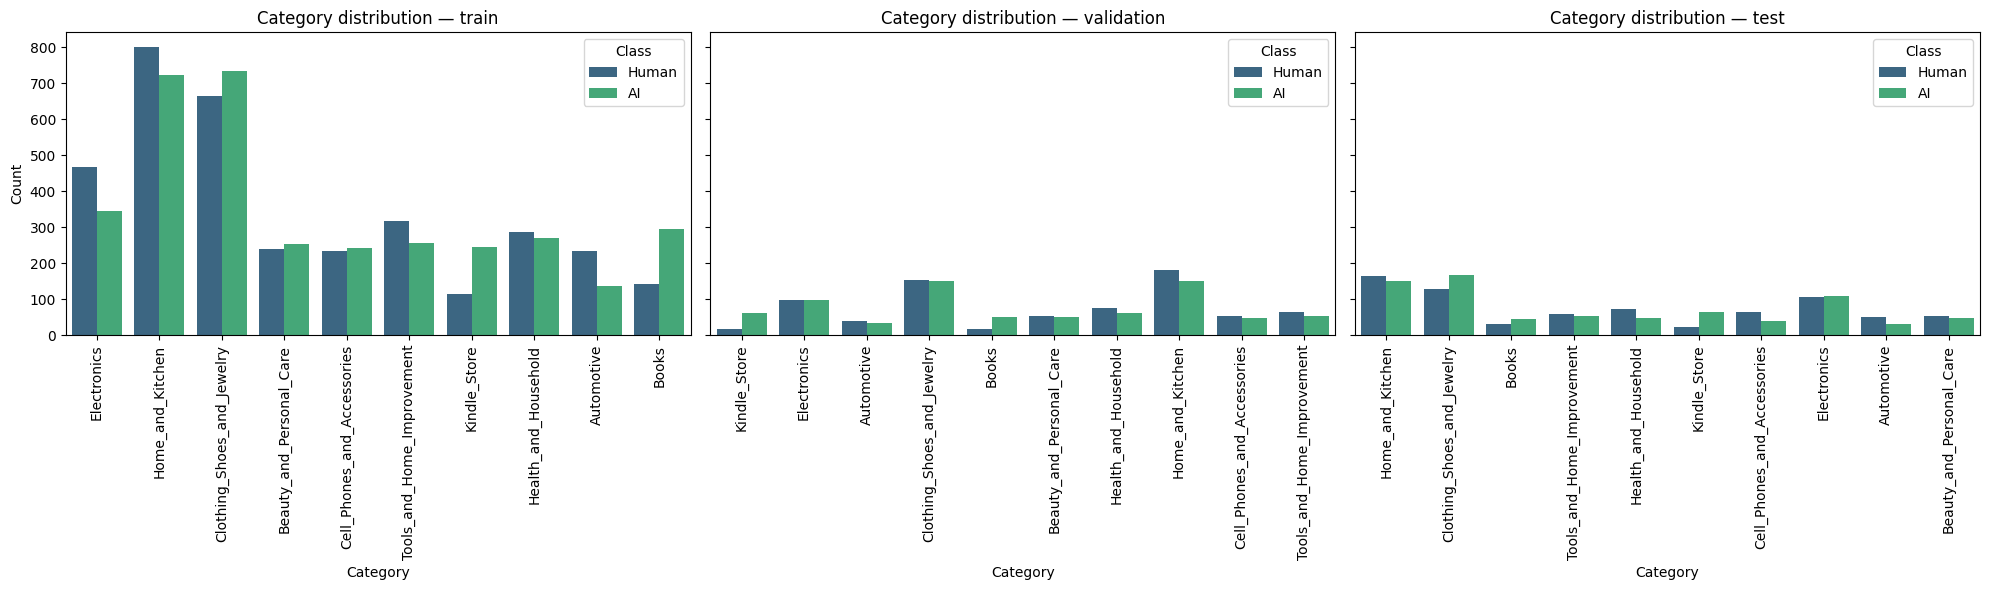

In [9]:
# --- Category distribution plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, (name, df) in zip(axes, [("train", df_train), ("validation", df_val),
                                 ("test", df_test)]):
    sns.countplot(data=df, x="category", hue="ai_generated", palette="viridis", ax=ax)
    ax.set_title(f"Category distribution — {name}")
    ax.set_xlabel("Category"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=90)
    ax.legend(title="Class", labels=["Human", "AI"])
plt.tight_layout()
plt.show()

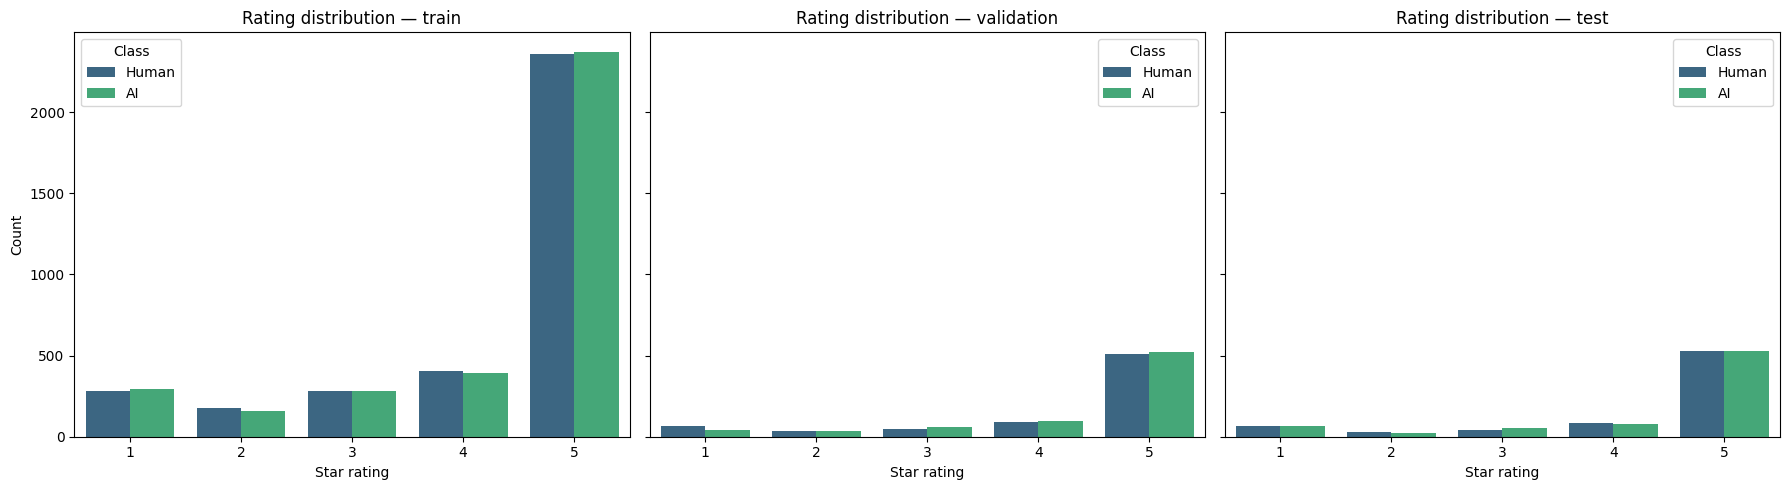

In [10]:
# --- Rating distribution by class ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (name, df) in zip(axes, [("train", df_train), ("validation", df_val),
                                 ("test", df_test)]):
    sns.countplot(data=df, x="rating", hue="ai_generated", palette="viridis",
                  order=sorted(df["rating"].unique()), ax=ax)
    ax.set_title(f"Rating distribution — {name}")
    ax.set_xlabel("Star rating"); ax.set_ylabel("Count")
    ax.legend(title="Class", labels=["Human", "AI"])
plt.tight_layout()
plt.show()

In [11]:
# --- Review length analysis ---
# Length is measured in whitespace-separated tokens.
def add_token_length(df):
    df = df.copy()
    df["n_tokens"] = df["text"].astype(str).str.split().str.len()
    return df

train_len = add_token_length(df_train)

# Numeric summary per class.
print("Token-length summary by class (training set):")
display(train_len.groupby("ai_generated")["n_tokens"].describe().round(1))

# 95th percentile informs the MAX_LEN choice.
p95 = train_len["n_tokens"].quantile(0.95)
print(f"\n95th percentile of review length: {p95:.0f} tokens.")
print(f"MAX_LEN is set to {MAX_LEN}, which therefore covers ~95%+ of reviews; "
      f"longer reviews are truncated.")

Token-length summary by class (training set):


,count,mean,std,min,25%,50%,75%,max
ai_generated,,,,,,,,
0,3500.0,41.9,59.3,1.0,11.0,24.0,48.0,887.0
1,3500.0,22.2,11.1,1.0,14.0,23.0,29.0,70.0



95th percentile of review length: 92 tokens.
MAX_LEN is set to 128, which therefore covers ~95%+ of reviews; longer reviews are truncated.


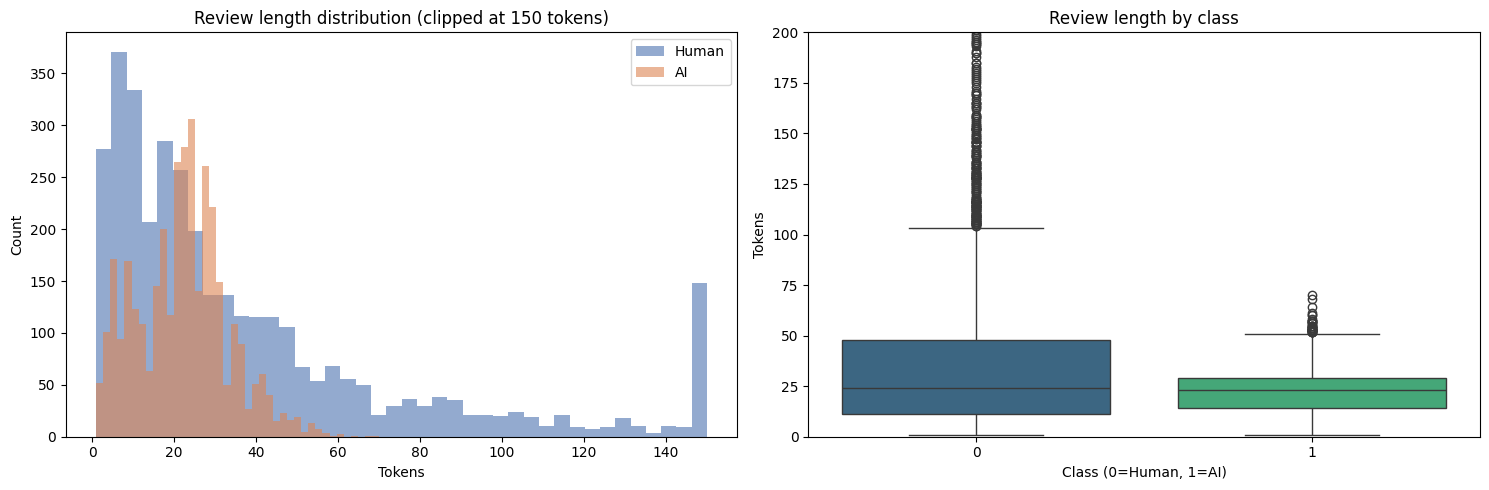

In [13]:
# --- Length distribution figure ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram (clipped at 150 tokens for readability).
for cls, lab, col in [(0, "Human", "#4C72B0"), (1, "AI", "#DD8452")]:
    sub = train_len.loc[train_len["ai_generated"] == cls, "n_tokens"].clip(upper=150)
    axes[0].hist(sub, bins=40, alpha=0.6, label=lab, color=col)
axes[0].set_title("Review length distribution (clipped at 150 tokens)")
axes[0].set_xlabel("Tokens"); axes[0].set_ylabel("Count"); axes[0].legend()

# Boxplot
sns.boxplot(data=train_len, x="ai_generated", y="n_tokens", palette="viridis", ax=axes[1])
axes[1].set_title("Review length by class")
axes[1].set_xlabel("Class (0=Human, 1=AI)"); axes[1].set_ylabel("Tokens")
axes[1].set_ylim(0, 200)

plt.tight_layout()
plt.show()

In [14]:
# --- N-gram leakage check ---
def top_ngrams_per_class(df, text_col="text", label_col="ai_generated",
                         ngram_range=(1, 3), top_k=25):
    out = {}
    for cls in sorted(df[label_col].unique()):
        texts = df.loc[df[label_col] == cls, text_col].astype(str).tolist()
        vec = CountVectorizer(ngram_range=ngram_range, min_df=5, stop_words="english")
        X = vec.fit_transform(texts)
        counts = X.sum(axis=0).A1
        vocab = vec.get_feature_names_out()
        top = sorted(zip(vocab, counts), key=lambda x: -x[1])[:top_k]
        out[cls] = pd.DataFrame(top, columns=["ngram", "count"])
    return out

ngrams = top_ngrams_per_class(df_train)
print("Top n-grams — HUMAN class (0):")
display(ngrams[0])
print("Top n-grams — AI class (1):")
display(ngrams[1])

Top n-grams — HUMAN class (0):


,ngram,count
0,like,747
1,great,733
2,good,594
3,just,583
4,use,536
5,love,483
6,easy,448
7,really,421
8,nice,400
9,fit,298


Top n-grams — AI class (1):


,ngram,count
0,great,507
1,ve,489
2,bit,376
3,highly,323
4,recommend,319
5,highly recommend,301
6,love,268
7,like,245
8,perfectly,241
9,perfect,230


## 3. Modelling setup

All experiments reuse the same set of helper functions, defined once here.
This guarantees that the in-distribution and cross-domain experiments use an
identical training and evaluation procedure.

In [20]:
# --- Tokenizer ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [21]:
# --- Helper functions ---

def prep_dataset(df: pd.DataFrame) -> Dataset:
    """Convert a dataframe slice into a tokenized HuggingFace Dataset
    containing only the columns the Trainer needs."""
    ds = Dataset.from_pandas(
        df[["text", "ai_generated"]].rename(columns={"ai_generated": "label"}),
        preserve_index=False,
    )
    ds = ds.map(
        lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN),
        batched=True,
    )
    # Drop the raw text so the data collator only sees tensors.
    return ds.remove_columns(["text"])


def fresh_model():
    """A new model is created for every training run so no information
    leaks between experiments or LOCO folds."""
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2,
        id2label={0: "human", 1: "ai"}, label2id={"human": 0, "ai": 1},
    )


def compute_metrics(eval_pred):
    """Metrics computed by the Trainer on the validation set each epoch."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.from_numpy(logits), dim=-1)[:, 1].numpy()
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1,
        "macro_precision": p,
        "macro_recall": r,
        "roc_auc": roc_auc_score(labels, probs),
    }


def per_class_metrics(y_true, y_pred, y_prob):
    """Full metric set including per-class precision/recall/F1.
    Per-class metrics are essential for diagnosing prior-shift effects in the
    cross-domain experiment: a symmetric drop indicates genuine domain shift,
    while a one-sided collapse indicates a class-prior artefact."""
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0)
    mp, mr, mf1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": mf1, "macro_precision": mp, "macro_recall": mr,
        "roc_auc": roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float("nan"),
        "precision_human": p[0], "recall_human": r[0], "f1_human": f1[0],
        "precision_ai": p[1], "recall_ai": r[1], "f1_ai": f1[1],
    }


def train_one(train_df, val_df, output_dir, seed=GLOBAL_SEED, epochs=EPOCHS, lr=LEARNING_RATE):
    """Fine-tune one DistilBERT model and return the Trainer with the best
    epoch's weights loaded. Used by every experiment in the notebook."""
    set_all_seeds(seed)
    args = TrainingArguments(
        output_dir=str(output_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=TRAIN_BATCH,
        per_device_eval_batch_size=EVAL_BATCH,
        learning_rate=lr,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,                 # keep only the best checkpoint
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),     # mixed precision: less memory
        logging_steps=50,
        seed=seed,
        report_to="none",
        disable_tqdm=True,                  # cleaner logs inside loops
    )
    trainer = Trainer(
        model=fresh_model(), args=args,
        train_dataset=prep_dataset(train_df),
        eval_dataset=prep_dataset(val_df),
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )
    trainer.train()
    return trainer


def predict_on_df(trainer, df):
    """Run a trained model on an arbitrary dataframe slice and return the
    full per-class metric set."""
    out = trainer.predict(prep_dataset(df))
    logits = out.predictions
    y_true = out.label_ids
    y_pred = np.argmax(logits, axis=-1)
    y_prob = torch.softmax(torch.from_numpy(logits), dim=-1)[:, 1].numpy()
    return per_class_metrics(y_true, y_pred, y_prob)


def free_memory(*objs):
    """Delete objects and clear the GPU cache between training runs
    (important on memory-constrained GPUs)."""
    for o in objs:
        del o
    gc.collect()
    torch.cuda.empty_cache()

## 4. In-distribution detection (headline result)

DistilBERT is trained on df_train, fine-tuned on df_val, and evaluated on the held-out test set. The best perfoming model is run on **three different seeds** and reported as mean ± standard deviation.

### 4.1 Hyperparameter Tuning 

Due to computational constraints, the grid search is conducted only on the learning rate and on the GLOBAL_SEED.

In [ ]:
# --- Hyperparameter Tuning using GLOBAL_SEED ---
print(f"--- Starting Grid Search on Seed {GLOBAL_SEED} ---")

best_lr = None
best_val_score = -1
seed42_test_metrics = None
tuning_rows = []

for lr in LR_CANDIDATES:
    print(f"\nTesting Learning Rate: {lr}")
    t0 = time.time()

    # Train model on GLOBAL_SEED
    trainer_tuning = train_one(
        df_train, df_val,
        output_dir=MODELS_DIR / f"tuning_lr_{lr}",
        seed=GLOBAL_SEED,
        lr=lr
    )

    # Evaluate on df_val to find the best configuration
    val_metrics = predict_on_df(trainer_tuning, df_val)
    val_macro_f1 = val_metrics["macro_f1"]

    # Evaluate on df_test now so no need to retrain this seed later
    test_metrics = predict_on_df(trainer_tuning, df_test)

    tuning_rows.append({
        "learning_rate": lr,
        "val_macro_f1": val_macro_f1,
        "minutes": (time.time() - t0) / 60
    })

    # Keep track of the best setting and save model
    if val_macro_f1 > best_val_score:
        best_val_score = val_macro_f1
        best_lr = lr
        seed42_test_metrics = test_metrics

        # Save the new best model
        trainer_tuning.save_model(str(MODELS_DIR / "headline_seed42_final"))
        tokenizer.save_pretrained(str(MODELS_DIR / "headline_seed42_final"))
        print(f"*** New best model found and saved to disk (LR: {lr}) ***")

    # Free memory before the next run
    free_memory(trainer_tuning)

tuning_df = pd.DataFrame(tuning_rows)
print("\nGrid Search Results:")
display(tuning_df.round(4))
print(f"\nOptimal Learning Rate found: {best_lr} (Val Macro F1: {best_val_score:.4f})")

# Overwrite global LEARNING_RATE so subsequent cells use the optimized value automatically
LEARNING_RATE = best_lr

--- Starting Grid Search on Seed 42 ---

Testing Learning Rate: 1e-05


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

*** New best model found and saved to disk (LR: 5e-05) ***

Grid Search Results:


,learning_rate,val_macro_f1,minutes
0,0.0,0.9593,2.1995
1,0.0,0.9700,1.9535
2,0.0,0.9727,2.6289



Optimal Learning Rate found: 5e-05 (Val Macro F1: 0.9727)


### 4.2 Robustness Check

The best model ist now trained on two additional random seeds to check its robustness. This section includes the final in-distribution result reported in the paper with mean +/- std across seeds.

In [ ]:
# --- 2: In-distribution training for remaining seeds ---
print(f"\n--- Evaluating Best Model (LR={LEARNING_RATE}) on remaining seeds ---")

# Start final results list 
seed_rows = [{"seed": GLOBAL_SEED, **seed42_test_metrics, "minutes": "included_in_tuning"}]

for seed in SEEDS:
    print(f"\n=== Seed {seed} ===")
    t0 = time.time()

    # Train using the optimal lr found in the tuning phase
    trainer_s = train_one(
        df_train, df_val,
        output_dir=MODELS_DIR / f"headline_seed{seed}",
        seed=seed,
        lr=LEARNING_RATE
    )

    # Evaluate on test dataset
    metrics = predict_on_df(trainer_s, df_test)
    seed_rows.append({"seed": seed, **metrics, "minutes": (time.time() - t0) / 60})

    free_memory(trainer_s)

# Save and display headline results
seed_df = pd.DataFrame(seed_rows)
seed_df.to_csv(RESULTS_DIR / "headline_seed_replicates.csv", index=False)
print("\nFinal Replicated Results:")
display(seed_df.round(4))


--- Evaluating Best Model (LR=5e-05) on remaining seeds ---

=== Seed 1337 ===


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'train_runtime': '125.6', 'train_samples_per_second': '167.2', 'train_steps_per_second': '10.46', 'train_loss': '0.1079', 'epoch': '3'}


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]


Final Replicated Results:


,seed,accuracy,macro_f1,macro_precision,macro_recall,roc_auc,precision_human,recall_human,f1_human,precision_ai,recall_ai,f1_ai,minutes
0,42,0.9567,0.9567,0.9573,0.9567,0.9929,0.9737,0.9387,0.9559,0.9408,0.9747,0.9574,included_in_tuning
1,1337,0.9533,0.9533,0.9549,0.9533,0.9931,0.9816,0.9240,0.9519,0.9282,0.9827,0.9547,2.014813
2,2024,0.9587,0.9586,0.9596,0.9587,0.9930,0.9804,0.9360,0.9577,0.9388,0.9813,0.9596,2.176625


In [ ]:
# --- Headline summary ---
# This table is the in-distribution result reported in the paper with mean +/- std across seeds.
metric_cols = ["accuracy", "macro_f1", "macro_precision", "macro_recall",
               "roc_auc", "recall_human", "recall_ai"]
summary = seed_df[metric_cols].agg(["mean", "std"]).T
summary.columns = ["mean", "std"]
display(summary.round(4))
summary.to_csv(RESULTS_DIR / "headline_summary.csv")

,mean,std
accuracy,0.9562,0.0027
macro_f1,0.9562,0.0027
macro_precision,0.9573,0.0024
macro_recall,0.9562,0.0027
roc_auc,0.9930,0.0001
recall_human,0.9329,0.0078
recall_ai,0.9796,0.0043


### 4.3 Per-category in-distribution performance

Using the headline model trained on **all** categories, performance is
broken down per product category on the test set. This shows whether the
strong overall result is uniform or hides weak categories.

In [ ]:
# --- Load the optimized model saved before ---
print("Loading best model from disk for evaluation")
best_model_path = str(MODELS_DIR / "headline_seed42_final")
best_model = AutoModelForSequenceClassification.from_pretrained(best_model_path).to('cuda')

# Create an inference-only trainer
headline_trainer = Trainer(
    model=best_model,
    data_collator=DataCollatorWithPadding(tokenizer)
)

# --- Per-category evaluation of the headline model ---
per_cat_rows = []
for cat in sorted(df_test["category"].unique()):
    sub = df_test[df_test["category"] == cat]
    per_cat_rows.append({"category": cat, "n_test": len(sub),
                         **predict_on_df(headline_trainer, sub)})

per_cat_df = (pd.DataFrame(per_cat_rows)
              .sort_values("macro_f1", ascending=False)
              .reset_index(drop=True))
per_cat_df.to_csv(RESULTS_DIR / "per_category_in_distribution.csv", index=False)
display(per_cat_df.round(3))

# Free memory again once we are done evaluating!
free_memory(headline_trainer)
import gc; gc.collect(); torch.cuda.empty_cache()

Loading best model from disk for evaluation


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Map:   0%|          | 0/79 [00:00<?, ? examples/s]

Map:   0%|          | 0/101 [00:00<?, ? examples/s]

Map:   0%|          | 0/78 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/121 [00:00<?, ? examples/s]

Map:   0%|          | 0/312 [00:00<?, ? examples/s]

Map:   0%|          | 0/86 [00:00<?, ? examples/s]

Map:   0%|          | 0/110 [00:00<?, ? examples/s]

,category,n_test,accuracy,macro_f1,macro_precision,macro_recall,roc_auc,precision_human,recall_human,f1_human,precision_ai,recall_ai,f1_ai
0,Kindle_Store,86,0.988,0.985,0.992,0.978,0.998,1.000,0.957,0.978,0.984,1.000,0.992
1,Electronics,213,0.962,0.962,0.964,0.962,0.997,0.990,0.933,0.961,0.939,0.991,0.964
2,Home_and_Kitchen,312,0.962,0.962,0.962,0.963,0.993,0.993,0.933,0.962,0.931,0.993,0.961
3,Automotive,79,0.962,0.960,0.955,0.969,1.000,1.000,0.939,0.968,0.909,1.000,0.952
4,Health_and_Household,121,0.959,0.957,0.955,0.959,0.990,0.972,0.959,0.966,0.939,0.958,0.948
5,Tools_and_Home_Improvement,110,0.955,0.954,0.955,0.954,0.996,0.949,0.966,0.957,0.961,0.942,0.951
6,Cell_Phones_and_Accessories,104,0.952,0.949,0.947,0.951,0.991,0.969,0.954,0.961,0.925,0.949,0.937
7,Books,78,0.949,0.946,0.960,0.938,0.989,1.000,0.875,0.933,0.920,1.000,0.958
8,Clothing_Shoes_and_Jewelry,296,0.946,0.945,0.945,0.945,0.990,0.938,0.938,0.938,0.952,0.952,0.952
9,Beauty_and_Personal_Care,101,0.941,0.941,0.940,0.941,0.993,0.961,0.925,0.942,0.920,0.958,0.939


## 5. Leave-One-Category-Out (LOCO)

LOCO directly tests **cross-domain generalization**: for each product category
*C*, DistilBERT is trained on the nine other categories and evaluated on the
unseen category *C*. This method mirrors the realistic deployment scenario of a detector trained on
existing categories encountering a new one. A single seed is used per LOCO fold as variation *across
categories* is the quantity of interest and model was tested robust across different seeds in section 4.2.

In [ ]:
# --- Find all unique categories across the dataset ---
# We use df_test to get the categories, but they should be the same across all splits
categories = sorted(df_test["category"].unique())
print(f"Starting LOCO evaluation across {len(categories)} categories...\n")

# --- LOCO loop ---
loco_rows = []

for i, held_out in enumerate(categories, start=1):
    print(f"[{i}/{len(categories)}] Holding out: {held_out}")
    t0 = time.time()

    # 1. Train set = Original train set minus the held-out category
    tr_df = df_train[df_train["category"] != held_out].reset_index(drop=True)

    # 2. Validation set = Original validation set minus the held-out category
    va_df = df_val[df_val["category"] != held_out].reset_index(drop=True)

    # 3. Test set = ONLY the held-out category, from the untouched test set
    te_df = df_test[df_test["category"] == held_out].reset_index(drop=True)

    # Train using the optimal learning rate found in Cell 1
    fold_trainer = train_one(
        tr_df, va_df,
        output_dir=MODELS_DIR / "loco_tmp",
        seed=GLOBAL_SEED,
        lr=LEARNING_RATE   # <--- Use tuned LR
    )

    test_metrics = predict_on_df(fold_trainer, te_df)

    loco_rows.append({
        "held_out_category": held_out,
        "n_train": len(tr_df), "n_test": len(te_df),
        "pct_ai_in_train": round(tr_df["ai_generated"].mean(), 3),
        "pct_ai_in_test": round(te_df["ai_generated"].mean(), 3),
        **test_metrics,
        "minutes": round((time.time() - t0) / 60, 1),
    })

    free_memory(fold_trainer)

loco_df = (pd.DataFrame(loco_rows)
           .sort_values("macro_f1", ascending=False)
           .reset_index(drop=True))
loco_df.to_csv(RESULTS_DIR / "loco_results.csv", index=False)
display(loco_df.round(3))

Starting LOCO evaluation across 10 categories...

[1/10] Holding out: Automotive


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/6629 [00:00<?, ? examples/s]

Map:   0%|          | 0/1428 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'train_runtime': '106.1', 'train_samples_per_second': '181.8', 'train_steps_per_second': '11.37', 'train_loss': '0.0999', 'epoch': '3'}


Map:   0%|          | 0/110 [00:00<?, ? examples/s]

,held_out_category,n_train,n_test,pct_ai_in_train,pct_ai_in_test,accuracy,macro_f1,macro_precision,macro_recall,roc_auc,precision_human,recall_human,f1_human,precision_ai,recall_ai,f1_ai,minutes
0,Automotive,6629,79,0.507,0.380,0.975,0.973,0.973,0.973,0.998,0.980,0.980,0.980,0.967,0.967,0.967,2.1
1,Tools_and_Home_Improvement,6427,110,0.505,0.473,0.973,0.973,0.972,0.973,0.996,0.982,0.966,0.974,0.962,0.981,0.971,1.8
2,Kindle_Store,6640,86,0.490,0.733,0.977,0.970,0.970,0.970,0.988,0.957,0.957,0.957,0.984,0.984,0.984,2.1
3,Beauty_and_Personal_Care,6507,101,0.499,0.475,0.970,0.970,0.971,0.972,0.993,1.000,0.943,0.971,0.941,1.000,0.970,2.3
4,Electronics,6188,213,0.510,0.507,0.962,0.962,0.964,0.962,0.992,0.990,0.933,0.961,0.939,0.991,0.964,2.4
5,Health_and_Household,6443,121,0.501,0.397,0.942,0.939,0.941,0.938,0.988,0.946,0.959,0.952,0.936,0.917,0.926,2.6
6,Books,6565,78,0.488,0.590,0.936,0.933,0.942,0.927,0.993,0.966,0.875,0.918,0.918,0.978,0.947,3.4
7,Home_and_Kitchen,5477,312,0.507,0.478,0.933,0.933,0.934,0.934,0.988,0.973,0.896,0.933,0.895,0.973,0.932,1.6
8,Cell_Phones_and_Accessories,6523,104,0.499,0.375,0.923,0.920,0.914,0.933,0.983,0.983,0.892,0.935,0.844,0.974,0.905,3.4
9,Clothing_Shoes_and_Jewelry,5601,296,0.494,0.564,0.919,0.918,0.917,0.923,0.986,0.872,0.953,0.911,0.961,0.892,0.925,2.0


In [ ]:


loco_avg = pd.DataFrame([{
    "held_out_category": "AVERAGE",
    "accuracy": loco_df["accuracy"].mean(),
    "macro_f1": loco_df["macro_f1"].mean(),
    "macro_precision": loco_df["macro_precision"].mean(),
    "macro_recall": loco_df["macro_recall"].mean(),
    "precision_human": loco_df["precision_human"].mean(),
    "recall_human": loco_df["recall_human"].mean(),
    "f1_human": loco_df["f1_human"].mean(),
    "precision_ai": loco_df["precision_ai"].mean(),
    "recall_ai": loco_df["recall_ai"].mean(),
    "f1_ai": loco_df["f1_ai"].mean(),
    "n_test": loco_df["n_test"].sum(),
}])

print("=== LOCO Average ===")
display(loco_avg.round(4))

=== LOCO Average ===


,held_out_category,accuracy,macro_f1,macro_precision,macro_recall,precision_human,recall_human,f1_human,precision_ai,recall_ai,f1_ai,n_test
0,AVERAGE,0.951,0.9491,0.9498,0.9505,0.9649,0.9354,0.9492,0.9347,0.9657,0.9491,1500


### 5.1 Generalization-gap analysis

The per-category in-distribution result and the LOCO result are compared. 
Because both use models trained on the same pool, the **gap** isolates the 
effect of a category being absent from training.

A correlation between training-set size and LOCO performance is also computed,
to test whether residual variation is explained by *data availability* rather
than by *domain difficulty*.

In [60]:
# --- Merge in-distribution vs LOCO ---
merged = (
    per_cat_df[["category", "macro_f1", "n_test"]]
    .rename(columns={"macro_f1": "in_distribution_f1"})
    .merge(
        loco_df[["held_out_category", "macro_f1", "n_train"]]
        .rename(columns={"held_out_category": "category", "macro_f1": "loco_f1"}),
        on="category",
    )
)
merged["gap"] = merged["in_distribution_f1"] - merged["loco_f1"]
merged = merged.sort_values("gap", ascending=False).reset_index(drop=True)
merged.to_csv(RESULTS_DIR / "generalization_comparison.csv", index=False)
display(merged.round(3))


,category,in_distribution_f1,n_test,loco_f1,n_train,gap
0,Cell_Phones_and_Accessories,0.949,104,0.920,6523,0.029
1,Home_and_Kitchen,0.962,312,0.933,5477,0.029
2,Clothing_Shoes_and_Jewelry,0.945,296,0.918,5601,0.027
3,Health_and_Household,0.957,121,0.939,6443,0.018
4,Kindle_Store,0.985,86,0.970,6640,0.015
5,Books,0.946,78,0.933,6565,0.013
6,Electronics,0.962,213,0.962,6188,0.000
7,Automotive,0.960,79,0.973,6629,-0.013
8,Tools_and_Home_Improvement,0.954,110,0.973,6427,-0.018
9,Beauty_and_Personal_Care,0.941,101,0.970,6507,-0.030


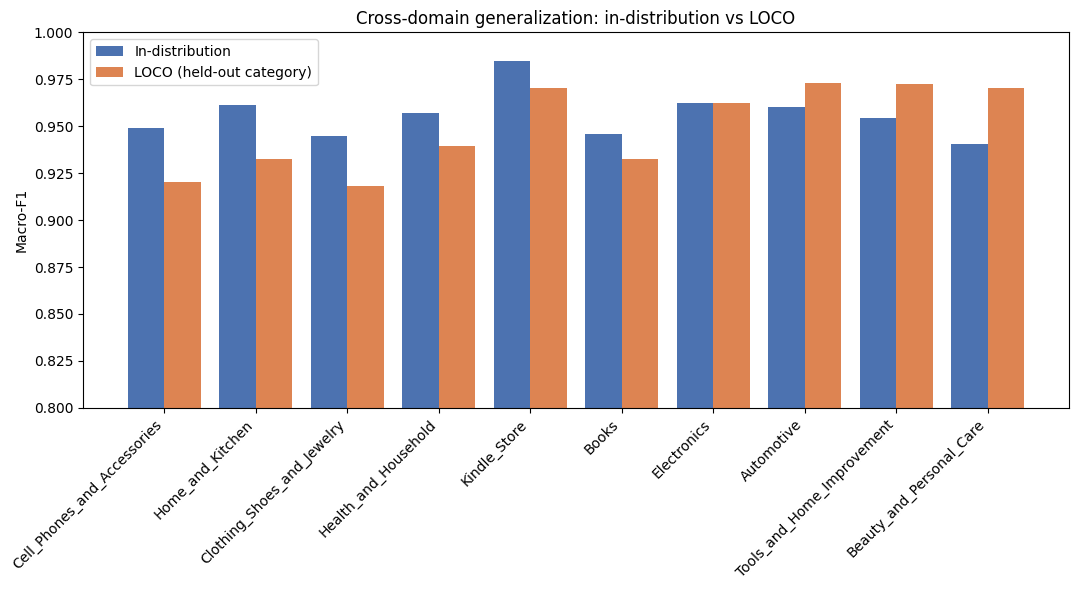

In [34]:
# --- Generalization-gap figure ---
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(merged))
ax.bar(x - 0.2, merged["in_distribution_f1"], width=0.4,
       label="In-distribution", color="#4C72B0")
ax.bar(x + 0.2, merged["loco_f1"], width=0.4,
       label="LOCO (held-out category)", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(merged["category"], rotation=45, ha="right")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0.8, 1.0)   # zoomed: all values are high; this makes gaps visible
ax.set_title("Cross-domain generalization: in-distribution vs LOCO")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "generalization_gap.png", dpi=200, bbox_inches="tight")
plt.show()

Pearson r (n_train vs LOCO macro-F1) = 0.509


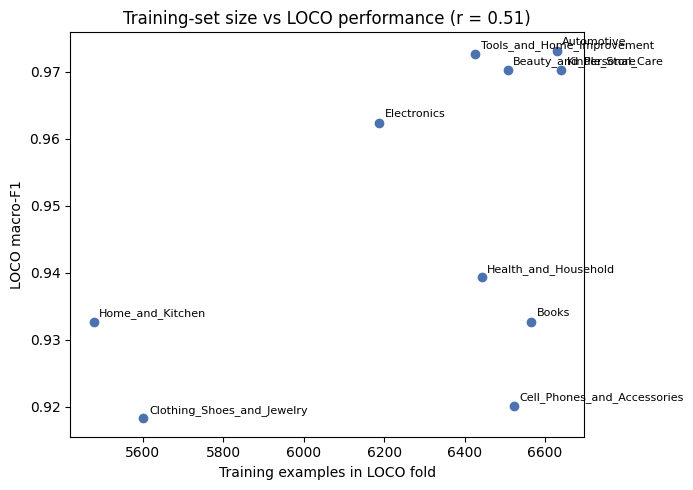

In [ ]:
# --- Does training-set size explain LOCO performance? ---
# Pearson correlation between the number of training examples available in a LOCO fold and that fold's macro-F1. A strong positive correlation supports
# the interpretation that data quantity, not domain identity, drives the gap.
corr = loco_df["n_train"].corr(loco_df["macro_f1"])
print(f"Pearson r (n_train vs LOCO macro-F1) = {corr:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(loco_df["n_train"], loco_df["macro_f1"], color="#4C72B0")
for _, row in loco_df.iterrows():
    ax.annotate(row["held_out_category"], (row["n_train"], row["macro_f1"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Training examples in LOCO fold")
ax.set_ylabel("LOCO macro-F1")
ax.set_title(f"Training-set size vs LOCO performance (r = {corr:.2f})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "loco_size_correlation.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Error analysis

Error analysis on the headline model. Absolute as well as well as normalized errors are reported.

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

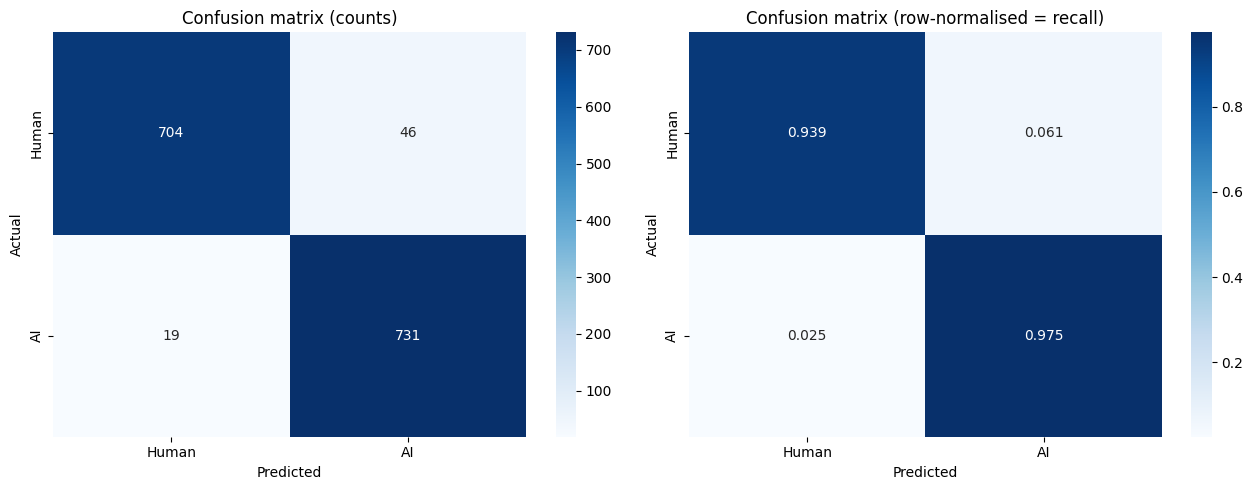


Classification report (test set):
              precision    recall  f1-score   support

       human       0.97      0.94      0.96       750
          ai       0.94      0.97      0.96       750

    accuracy                           0.96      1500
   macro avg       0.96      0.96      0.96      1500
weighted avg       0.96      0.96      0.96      1500



In [ ]:
# --- Confusion matrices: raw counts and row-normalised ---
# Load the optimized model, if not already in memory
try:
    headline_trainer
except NameError:
    print("Loading best model from disk for error analysis...")
    best_model_path = str(MODELS_DIR / "headline_seed42_final")
    best_model = AutoModelForSequenceClassification.frompretrained(best_model_path).to('cuda')
    headline_trainer = Trainer(
        model=best_model,
        data_collator=DataCollatorWithPadding(tokenizer)
    )

# Generate predictions
pred_out = headline_trainer.predict(prep_dataset(df_test))
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = pred_out.label_ids

cm = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = ["Human", "AI"]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title("Confusion matrix (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Blues", ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title("Confusion matrix (row-normalised = recall)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nClassification report (test set):")
print(classification_report(y_true, y_pred, target_names=["human", "ai"]))

In [ ]:
# --- Qualitative inspection of misclassified reviews ---
test_eval = df_test.reset_index(drop=True).copy()
test_eval["pred"] = y_pred
test_eval["correct"] = test_eval["pred"] == test_eval["ai_generated"]
test_eval["n_tokens"] = test_eval["text"].astype(str).str.split().str.len()

errors = test_eval[~test_eval["correct"]].copy()
fp = errors[errors["ai_generated"] == 0]   # human wrongly flagged as AI
fn = errors[errors["ai_generated"] == 1]   # AI wrongly accepted as human
print(f"Misclassified: {len(errors)} total -> "
      f"{len(fp)} false positives (human->AI), "
      f"{len(fn)} false negatives (AI->human)")
print(f"Mean length  -> false positives: {fp['n_tokens'].mean():.1f} tokens, "
      f"false negatives: {fn['n_tokens'].mean():.1f} tokens, "
      f"correct: {test_eval[test_eval['correct']]['n_tokens'].mean():.1f} tokens")

# Export a readable sample for manual inspection.
sample_cols = ["category", "rating", "n_tokens", "ai_generated", "pred", "text"]
err_sample = errors.sample(min(50, len(errors)), random_state=GLOBAL_SEED)
err_sample[sample_cols].to_csv(RESULTS_DIR / "error_sample.csv", index=False)
display(err_sample[sample_cols].head(25))

################################
'''
check interpretation again or drop
'''

Misclassified: 65 total -> 46 false positives (human->AI), 19 false negatives (AI->human)
Mean length  -> false positives: 21.0 tokens, false negatives: 8.0 tokens, correct: 31.0 tokens


,category,rating,n_tokens,ai_generated,pred,text
1293,Clothing_Shoes_and_Jewelry,5,2,1,0,Love these!
1412,Clothing_Shoes_and_Jewelry,5,14,0,1,Cool style and durable sandals. Very impressed...
6,Health_and_Household,5,6,1,0,"Love this oil, helps me sleep."
1138,Home_and_Kitchen,5,35,0,1,I read the other reviews but decided to try an...
172,Clothing_Shoes_and_Jewelry,3,46,0,1,"I love the design of this shirt, but it had a ..."
1418,Electronics,5,46,0,1,I am now able to keep everything plugged in at...
565,Cell_Phones_and_Accessories,5,16,0,1,"Economical, easy to attach and sensitive to th..."
365,Clothing_Shoes_and_Jewelry,5,2,1,0,Beautiful piece.
1487,Clothing_Shoes_and_Jewelry,5,7,1,0,Love this dress! Very breezy and cute.
865,Home_and_Kitchen,4,33,0,1,"Assembles quite easily, except for the dischar..."


' \ncheck interpretation again or drop\n'

## 7. Length-controlled robustness check

The EDA showed AI reviews occupy a narrower length range than human reviews.
This raises the question of whether the detector relies on **review length**
rather than **writing style**.

Two checks are run on the headline model:

1. **Length-stratified evaluation** — macro-F1 within token-length bands. Bands
   where *both* classes are well represented are the informative ones: strong
   performance there means the model discriminates within a fixed length range.
2. **Length-matched evaluation** — within each band, equal numbers of human and
   AI reviews are sampled, so the length distribution is identical for both
   classes. If performance stays high, length is likely not the explanation.

In [ ]:
# --- 7.1 Length-stratified evaluation ---
bins   = [0, 15, 25, 40, 70, 10_000]
blabels = ["1-15", "16-25", "26-40", "41-70", "70+"]
test_eval["len_bin"] = pd.cut(test_eval["n_tokens"], bins=bins, labels=blabels)

strat_rows = []
for b in blabels:
    sub = test_eval[test_eval["len_bin"] == b]
    if len(sub) < 20:                       # skip bands too small to be reliable
        continue
    n_h = int((sub["ai_generated"] == 0).sum())
    n_a = int((sub["ai_generated"] == 1).sum())
    strat_rows.append({"len_bin": b, "n": len(sub), "n_human": n_h, "n_ai": n_a,
                       **predict_on_df(headline_trainer, sub)})

strat_df = pd.DataFrame(strat_rows)
strat_df.to_csv(RESULTS_DIR / "length_stratified.csv", index=False)
display(strat_df[["len_bin", "n", "n_human", "n_ai", "macro_f1",
                  "recall_human", "recall_ai"]].round(3))
print("Informative bands are those with both n_human and n_ai sizeable. "
      "High macro-F1 there indicates discrimination is not purely length-based.")

Map:   0%|          | 0/496 [00:00<?, ? examples/s]

Map:   0%|          | 0/379 [00:00<?, ? examples/s]

Map:   0%|          | 0/368 [00:00<?, ? examples/s]

Map:   0%|          | 0/161 [00:00<?, ? examples/s]

Map:   0%|          | 0/96 [00:00<?, ? examples/s]

,len_bin,n,n_human,n_ai,macro_f1,recall_human,recall_ai
0,1-15,496,274,222,0.925,0.931,0.919
1,16-25,379,123,256,0.963,0.902,1.000
2,26-40,368,137,231,0.974,0.942,0.996
3,41-70,161,120,41,0.946,0.942,1.000
4,70+,96,96,0,1.000,1.000,0.000


Informative bands are those with both n_human and n_ai sizeable. High macro-F1 there indicates discrimination is not purely length-based.


In [ ]:
# --- 7.2 Length-matched evaluation ---
# Within each length band, sample an equal number of human and AI reviews so
# the two classes share an identical length distribution.
matched_parts = []
for b in blabels:
    sub = test_eval[test_eval["len_bin"] == b]
    h = sub[sub["ai_generated"] == 0]
    a = sub[sub["ai_generated"] == 1]
    k = min(len(h), len(a))
    if k < 5:                               # band lacks one class -> skip
        continue
    matched_parts.append(h.sample(k, random_state=GLOBAL_SEED))
    matched_parts.append(a.sample(k, random_state=GLOBAL_SEED))

matched = pd.concat(matched_parts).reset_index(drop=True)
print(f"Length-matched subset: {len(matched)} reviews "
      f"({(matched["ai_generated"] == 0).sum()} human / "
      f"{(matched["ai_generated"] == 1).sum()} AI), "
      f"identical length distribution per class.")

matched_metrics = predict_on_df(headline_trainer, matched)
display(pd.DataFrame([matched_metrics]).round(3).T.rename(columns={0: "value"}))

print("\nIf macro-F1 here is close to the headline result, the detector relies on writing style rather than review length.")

Length-matched subset: 1046 reviews (523 human / 523 AI), identical length distribution per class.


Map:   0%|          | 0/1046 [00:00<?, ? examples/s]

,value
accuracy,0.946
macro_f1,0.945
macro_precision,0.946
macro_recall,0.946
roc_auc,0.990
precision_human,0.962
recall_human,0.927
f1_human,0.944
precision_ai,0.930
recall_ai,0.964



If macro-F1 here is close to the headline result, the detector relies on writing style rather than review length.


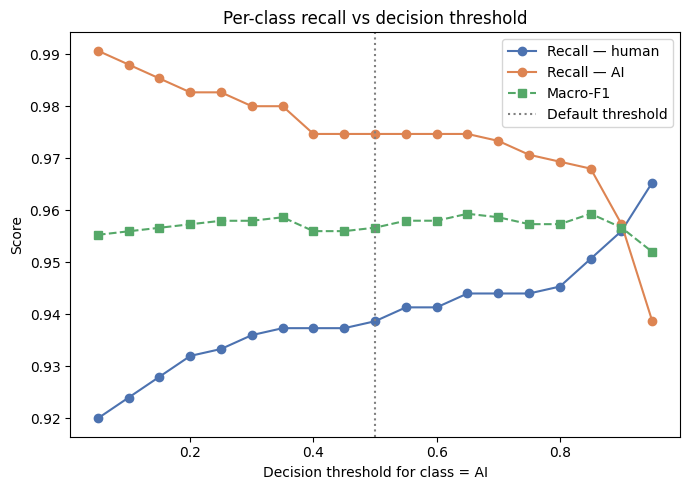

Macro-F1 is maximised at threshold = 0.85 (macro-F1 = 0.959), vs the default 0.50.


In [69]:
# --- Threshold sweep: per-class recall vs decision threshold ---
# The default threshold is 0.5. Because the test set / LOCO folds can be
# class-imbalanced, sweeping the threshold shows the precision-recall
# trade-off and lets us find a balance point.

# Define y_true_cal and y_prob_cal using variables from previous cells
y_true_cal = y_true
y_prob_cal = torch.softmax(torch.from_numpy(pred_out.predictions), dim=-1)[:, 1].numpy()

fig, ax = plt.subplots(figsize=(7, 5))

thresholds = np.linspace(0.05, 0.95, 19)
sweep_rows = []
for t in thresholds:
    y_pred_t = (y_prob_cal >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true_cal, y_pred_t, labels=[0, 1], zero_division=0)
    sweep_rows.append({"threshold": t,
                       "recall_human": r[0], "recall_ai": r[1],
                       "f1_human": f1[0], "f1_ai": f1[1],
                       "macro_f1": (f1[0] + f1[1]) / 2})
sweep_df = pd.DataFrame(sweep_rows)

# CHANGED: axes[1] is now simply ax
ax.plot(sweep_df["threshold"], sweep_df["recall_human"],
        marker="o", label="Recall — human", color="#4C72B0")
ax.plot(sweep_df["threshold"], sweep_df["recall_ai"],
        marker="o", label="Recall — AI", color="#DD8452")
ax.plot(sweep_df["threshold"], sweep_df["macro_f1"],
        marker="s", linestyle="--", label="Macro-F1", color="#55A868")
ax.axvline(0.5, color="grey", linestyle=":", label="Default threshold")
ax.set_xlabel("Decision threshold for class = AI")
ax.set_ylabel("Score")
ax.set_title("Per-class recall vs decision threshold")
ax.legend()

plt.tight_layout()
# CHANGED: updated filename to reflect it's just the sweep now
plt.savefig(RESULTS_DIR / "threshold_sweep.png", dpi=200, bbox_inches="tight")
plt.show()

# --- Threshold that maximises macro-F1 ---
best = sweep_df.loc[sweep_df["macro_f1"].idxmax()]
print(f"Macro-F1 is maximised at threshold = {best['threshold']:.2f} "
      f"(macro-F1 = {best['macro_f1']:.3f}), vs the default 0.50.")

sweep_df.to_csv(RESULTS_DIR / "threshold_sweep.csv", index=False)
